In [79]:
# =========================
# PASO 0: LIBRERÍAS
# =========================

import pandas as pd
import os

In [80]:
# =========================
# PASO 1: CARGAR DATOS
# =========================

clientes = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/clientes.csv")
facturacion = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/facturacion_mensual.csv")
churn = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/churn_target.csv")

In [81]:
print("NULOS:")
print(facturacion.isnull().sum())

print("\nDUPLICADOS:")
print(facturacion.duplicated().sum())

NULOS:
cliente_id                  0
fecha                       0
zona_id                     0
tipo_plan                9816
num_lineas                  0
cargo_base                  0
consumo_extra               0
descuento_aplicado          0
importe_total            9799
dias_retraso_pago           0
impago_flag                 0
variacion_consumo_pct       0
stress_calidad_lag          0
incidencia_masiva_lag       0
dtype: int64

DUPLICADOS:
4829


In [82]:
# =========================
# PASO 2: LIMPIEZA BÁSICA ANTES DEL MERGE
# =========================

clientes = clientes.drop_duplicates()
facturacion = facturacion.drop_duplicates()
churn = churn.drop_duplicates()

facturacion["fecha"] = pd.to_datetime(
    facturacion["fecha"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

churn["fecha"] = pd.to_datetime(
    churn["fecha"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

facturacion["tipo_plan"] = facturacion["tipo_plan"].fillna("Desconocido")

facturacion["importe_total"] = facturacion["importe_total"].fillna(
    facturacion["importe_total"].median()
)

print("CHECK FACTURACIÓN:")
print(facturacion.isnull().sum())
print("Duplicados:", facturacion.duplicated().sum())

CHECK FACTURACIÓN:
cliente_id               0
fecha                    0
zona_id                  0
tipo_plan                0
num_lineas               0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
stress_calidad_lag       0
incidencia_masiva_lag    0
dtype: int64
Duplicados: 0


In [83]:
facturacion = facturacion.drop_duplicates()

facturacion["tipo_plan"] = facturacion["tipo_plan"].fillna("desconocido")

facturacion["importe_total"] = facturacion["importe_total"].fillna(
    facturacion["importe_total"].median()
)

print("CHECK FINAL:")
print(facturacion.isnull().sum())
print("Duplicados:", facturacion.duplicated().sum())

CHECK FINAL:
cliente_id               0
fecha                    0
zona_id                  0
tipo_plan                0
num_lineas               0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
stress_calidad_lag       0
incidencia_masiva_lag    0
dtype: int64
Duplicados: 0


In [84]:
# =========================
# PASO 3: HACER MERGE
# =========================

df = facturacion.merge(churn, on=["cliente_id", "fecha"], how="inner")
df = df.merge(clientes, on="cliente_id", how="left")

df.head()

,cliente_id,fecha,zona_id_x,tipo_plan_x,num_lineas_x,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,...,poblacion_zona,edad,sexo,estado_civil,num_lineas_y,tipo_plan_y,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,2023-01-01,Z26,Prepago,2,43.65,6.98,0.0,50.62,0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
1,C000001,2023-01-02,Z26,Prepago,2,43.65,10.33,0.0,53.98,0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
2,C000001,2023-01-03,Z26,Prepago,2,43.65,10.87,0.0,54.52,0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
3,C000001,2023-01-04,Z26,Prepago,2,43.65,6.82,0.0,50.47,0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
4,C000001,2023-01-05,Z26,Prepago,2,43.65,13.26,0.0,56.90,0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0


In [85]:
# =========================
# PASO 4: ARREGLAR COLUMNAS REPETIDAS
# =========================

# Nos quedamos con la info buena de clientes
if "zona_id_y" in df.columns:
    df["zona_id"] = df["zona_id_y"]

if "tipo_plan_y" in df.columns:
    df["tipo_plan"] = df["tipo_plan_y"]

if "num_lineas_y" in df.columns:
    df["num_lineas"] = df["num_lineas_y"]

# Borramos columnas duplicadas que ya no necesitamos
columnas_borrar = [
    "zona_id_x", "zona_id_y",
    "tipo_plan_x", "tipo_plan_y",
    "num_lineas_x", "num_lineas_y"
]

df = df.drop(columns=[col for col in columnas_borrar if col in df.columns])

In [86]:
# =========================
# PASO 5: RELLENAR NULOS
# =========================

categoricas = [
    "sexo", "estado_civil", "tipo_plan",
    "tipo_dispositivo", "region", "tipo_zona"
]

for col in categoricas:
    if col in df.columns:
        df[col] = df[col].fillna("Desconocido")


numericas = [
    "edad", "ingreso_estimado", "antiguedad_meses",
    "cargo_base", "consumo_extra", "descuento_aplicado",
    "dias_retraso_pago", "impago_flag"
]

for col in numericas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [87]:
# =========================
# PASO 6: RECALCULAR IMPORTE TOTAL
# =========================

df["importe_total"] = (
    df["cargo_base"].fillna(0)
    + df["consumo_extra"].fillna(0)
    - df["descuento_aplicado"].fillna(0)
)

In [88]:
# =========================
# PASO 7: ORDENAR PARA CREAR VARIABLES LAG
# =========================

df = df.sort_values(["cliente_id", "fecha"])

In [89]:
# =========================
# PASO 8: CREAR VARIABLES DEL MES ANTERIOR
# =========================

df["factura_mes_anterior"] = df.groupby("cliente_id")["importe_total"].shift(1)
df["consumo_mes_anterior"] = df.groupby("cliente_id")["consumo_extra"].shift(1)
df["impago_mes_anterior"] = df.groupby("cliente_id")["impago_flag"].shift(1)
df["retraso_mes_anterior"] = df.groupby("cliente_id")["dias_retraso_pago"].shift(1)

df["subida_factura"] = df["importe_total"] - df["factura_mes_anterior"]
df["cambio_consumo"] = df["consumo_extra"] - df["consumo_mes_anterior"]

In [90]:
# =========================
# PASO 9: AHORA SÍ RELLENAR NULOS DE LOS LAGS
# =========================

columnas_lag = [
    "factura_mes_anterior",
    "consumo_mes_anterior",
    "impago_mes_anterior",
    "retraso_mes_anterior",
    "subida_factura",
    "cambio_consumo"
]

df[columnas_lag] = df[columnas_lag].fillna(0)

In [91]:
# =========================
# PASO 10: QUITAR DUPLICADOS FINALES
# =========================

df = df.drop_duplicates()

df.shape

(317579, 31)

In [92]:
# =========================
# PASO 11: CHECK FINAL
# =========================

print("SHAPE:")
print(df.shape)

print("\nTOTAL NULLS:")
print(df.isnull().sum().sum())

print("\nNULLS POR COLUMNA:")
print(df.isnull().sum())

print("\nDUPLICADOS:")
print(df.duplicated().sum())

print("\nTIPOS DE DATOS:")
print(df.dtypes)

SHAPE:
(317579, 31)

TOTAL NULLS:
0

NULLS POR COLUMNA:
cliente_id               0
fecha                    0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
stress_calidad_lag       0
incidencia_masiva_lag    0
churn                    0
region                   0
tipo_zona                0
poblacion_zona           0
edad                     0
sexo                     0
estado_civil             0
tipo_dispositivo         0
ingreso_estimado         0
antiguedad_meses         0
descuento_activo         0
zona_id                  0
tipo_plan                0
num_lineas               0
factura_mes_anterior     0
consumo_mes_anterior     0
impago_mes_anterior      0
retraso_mes_anterior     0
subida_factura           0
cambio_consumo           0
dtype: int64

DUPLICADOS:
0

TIPOS DE DATOS:
cliente_id                          str
fecha                 

In [93]:
# =========================
# ELIMINAR VALORES NEGATIVOS INCORRECTOS
# =========================

df = df[df["consumo_extra"] >= 0]

df = df[df["importe_total"] >= 0]

df = df[df["antiguedad_meses"] >= 0]

# Hipótesis del análisis

H1. Los clientes con impagos recientes tienen mayor probabilidad de churn.

H2. Los clientes con mayores retrasos de pago presentan más abandono.

H3. Una subida brusca de la factura puede aumentar el churn.

H4. Una caída del consumo puede indicar desinterés del cliente antes del churn.

H5. Los clientes con facturas más altas presentan mayor riesgo de abandono.

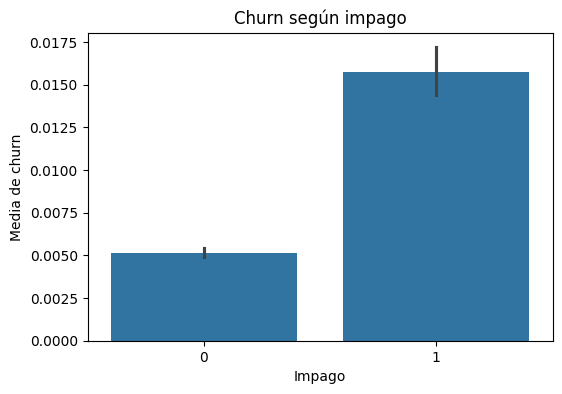

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="impago_flag",
    y="churn"
)

plt.title("Churn según impago")
plt.xlabel("Impago")
plt.ylabel("Media de churn")

plt.show()

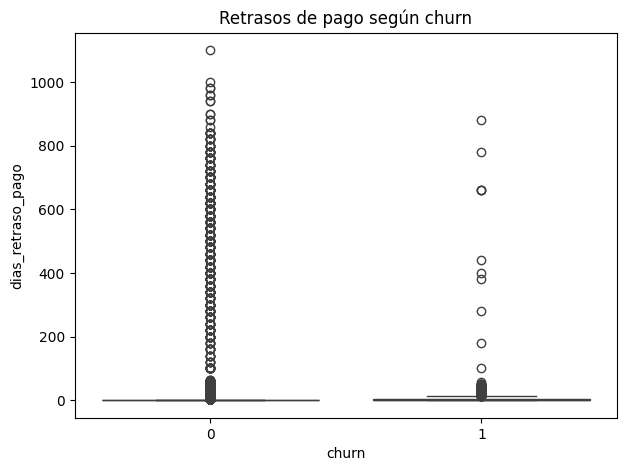

In [95]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="churn",
    y="dias_retraso_pago"
)

plt.title("Retrasos de pago según churn")

plt.show()

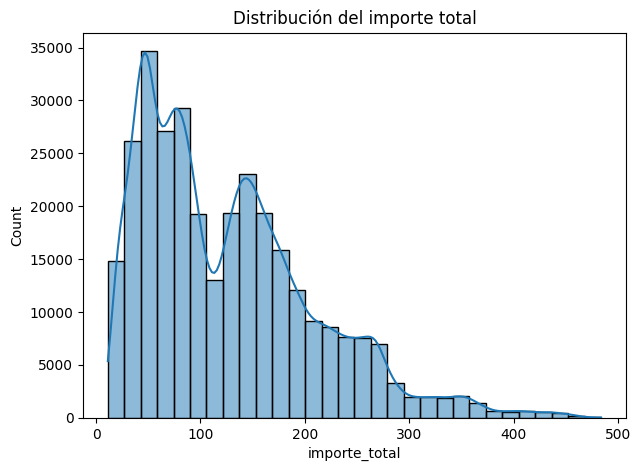

In [96]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["importe_total"],
    bins=30,
    kde=True
)

plt.title("Distribución del importe total")

plt.show()

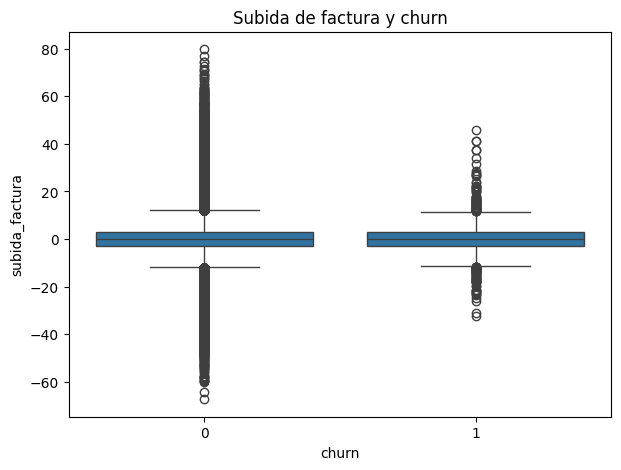

In [97]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="churn",
    y="subida_factura"
)

plt.title("Subida de factura y churn")

plt.show()

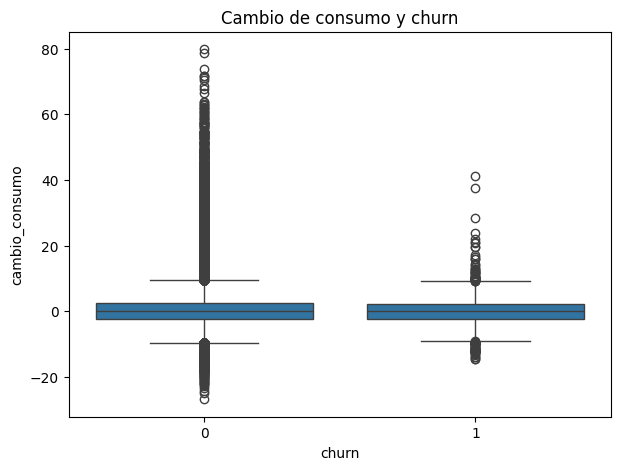

In [98]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="churn",
    y="cambio_consumo"
)

plt.title("Cambio de consumo y churn")

plt.show()

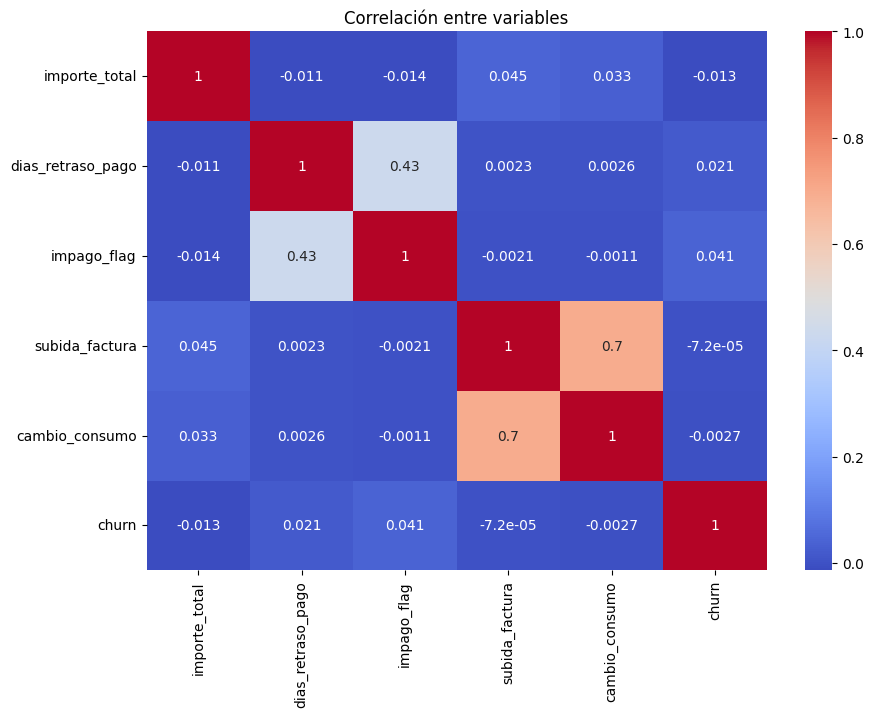

In [99]:
plt.figure(figsize=(10,7))

correlacion = df[[
    "importe_total",
    "dias_retraso_pago",
    "impago_flag",
    "subida_factura",
    "cambio_consumo",
    "churn"
]].corr()

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables")

plt.show()

In [100]:
# =====================================================
# ELIMINAR NEGATIVOS INCORRECTOS
# =====================================================

# factura_mes_anterior
if "factura_mes_anterior" in df.columns:
    df = df[df["factura_mes_anterior"] >= 0]

# consumo_mes_anterior
if "consumo_mes_anterior" in df.columns:
    df = df[df["consumo_mes_anterior"] >= 0]

print("Negativos incorrectos eliminados.")

Negativos incorrectos eliminados.


# Conclusiones

Se observa que los clientes con impagos y mayores retrasos de pago presentan un mayor nivel de churn.

También se aprecia que algunos clientes reducen su consumo antes de abandonar la compañía, lo que puede actuar como señal temprana de fuga.

Además, cambios bruscos en la factura parecen relacionarse con un mayor riesgo de abandono.

Por tanto, las variables de facturación y pagos pueden ayudar a detectar clientes con riesgo de churn.

In [101]:
# =========================
# CHECK FINAL DEL DATASET
# =========================

print("SHAPE:")
print(df.shape)

print("\nTOTAL DE NULOS:")
print(df.isnull().sum().sum())

print("\nNULOS POR COLUMNA:")
print(df.isnull().sum())

print("\nDUPLICADOS:")
print(df.duplicated().sum())

print("\nTIPOS DE DATOS:")
print(df.dtypes)

print("\nPRIMERAS FILAS:")
display(df.head())

SHAPE:
(305949, 31)

TOTAL DE NULOS:
0

NULOS POR COLUMNA:
cliente_id               0
fecha                    0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
stress_calidad_lag       0
incidencia_masiva_lag    0
churn                    0
region                   0
tipo_zona                0
poblacion_zona           0
edad                     0
sexo                     0
estado_civil             0
tipo_dispositivo         0
ingreso_estimado         0
antiguedad_meses         0
descuento_activo         0
zona_id                  0
tipo_plan                0
num_lineas               0
factura_mes_anterior     0
consumo_mes_anterior     0
impago_mes_anterior      0
retraso_mes_anterior     0
subida_factura           0
cambio_consumo           0
dtype: int64

DUPLICADOS:
0

TIPOS DE DATOS:
cliente_id                          str
fecha              

,cliente_id,fecha,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,...,descuento_activo,zona_id,tipo_plan,num_lineas,factura_mes_anterior,consumo_mes_anterior,impago_mes_anterior,retraso_mes_anterior,subida_factura,cambio_consumo
0,C000001,2023-01-01,43.65,6.98,0.0,50.63,0,0,0.000,0.0000,...,0,Z26,Prepago,2,0.00,0.00,0.0,0.0,0.00,0.00
1,C000001,2023-01-02,43.65,10.33,0.0,53.98,0,0,0.481,0.4104,...,0,Z26,Prepago,2,50.63,6.98,0.0,0.0,3.35,3.35
2,C000001,2023-01-03,43.65,10.87,0.0,54.52,0,0,0.052,0.4221,...,0,Z26,Prepago,2,53.98,10.33,0.0,0.0,0.54,0.54
3,C000001,2023-01-04,43.65,6.82,0.0,50.47,0,0,-0.372,0.4301,...,0,Z26,Prepago,2,54.52,10.87,0.0,0.0,-4.05,-4.05
4,C000001,2023-01-05,43.65,13.26,0.0,56.91,0,0,0.943,0.4486,...,0,Z26,Prepago,2,50.47,6.82,0.0,0.0,6.44,6.44


In [102]:
# =====================================================
# VER DÓNDE ESTÁN LOS VALORES NEGATIVOS
# =====================================================

import numpy as np

numericas = df.select_dtypes(include=np.number).columns

for col in numericas:
    
    negativos = df[df[col] < 0]
    
    if len(negativos) > 0:
        
        print("\n" + "="*60)
        print(f"VALORES NEGATIVOS EN: {col}")
        print("="*60)
        
        print(f"Cantidad: {len(negativos)}")
        
        display(
            negativos[[col]].head(10)
        )


VALORES NEGATIVOS EN: variacion_consumo_pct
Cantidad: 127572


,variacion_consumo_pct
3,-0.372
5,-0.208
6,-1.000
9,-1.000
12,-0.946
17,-0.145
18,-0.036
19,-0.363
20,-0.968
22,-1.000



VALORES NEGATIVOS EN: subida_factura
Cantidad: 133305


,subida_factura
3,-4.05
5,-2.76
6,-10.50
9,-3.13
12,-1.47
17,-1.70
18,-0.36
19,-3.50
20,-5.93
22,-1.81



VALORES NEGATIVOS EN: cambio_consumo
Cantidad: 127554


,cambio_consumo
3,-4.05
5,-2.76
6,-10.50
9,-3.13
12,-1.47
17,-1.70
18,-0.36
19,-3.50
20,-5.93
22,-1.81


In [103]:
# =====================================================
# LIMPIEZA FINAL - CALIDAD_LIMPIA
# =====================================================

import pandas as pd
import numpy as np

# Cargar dataset
calidad_limpia = pd.read_csv("data/processed/calidad_limpia.csv")

# Fecha correcta
calidad_limpia["fecha"] = pd.to_datetime(
    calidad_limpia["fecha"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Ordenar
calidad_limpia = calidad_limpia.sort_values(["zona_id", "fecha"])

# =====================================================
# 1. RELLENAR NULOS REALES
# =====================================================

cols_rellenar = [
    "cobertura_4g_pct",
    "cobertura_5g_pct",
    "latencia_ms"
]

for col in cols_rellenar:
    calidad_limpia[col] = calidad_limpia.groupby("zona_id")[col].transform(
        lambda x: x.fillna(x.median())
    )

# Si sigue quedando alguno
for col in cols_rellenar:
    calidad_limpia[col] = calidad_limpia[col].fillna(
        calidad_limpia[col].median()
    )

# =====================================================
# 2. VARIABLES TEMPORALES
# =====================================================

# Mes anterior
calidad_limpia["calidad_mes_anterior"] = calidad_limpia.groupby("zona_id")[
    "indice_calidad_global"
].shift(1)

# Media móvil
calidad_limpia["calidad_media_3_meses"] = calidad_limpia.groupby("zona_id")[
    "indice_calidad_global"
].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# Primer mes -> usar valor actual
calidad_limpia["calidad_mes_anterior"] = calidad_limpia[
    "calidad_mes_anterior"
].fillna(calidad_limpia["indice_calidad_global"])

# =====================================================
# CHECK FINAL
# =====================================================

print("="*70)
print("CHECK FINAL - CALIDAD_LIMPIA")
print("="*70)

print("\n1. SHAPE:")
print(calidad_limpia.shape)

print("\n2. TOTAL NULLS:")
print(calidad_limpia.isnull().sum().sum())

print("\n3. NULLS PER COLUMN:")
print(calidad_limpia.isnull().sum())

print("\n4. DUPLICADOS:")
print(calidad_limpia.duplicated().sum())

print("\n5. RANGO FECHAS:")
print("Min:", calidad_limpia["fecha"].min())
print("Max:", calidad_limpia["fecha"].max())

# =====================================================
# GUARDAR
# =====================================================

calidad_limpia.to_csv(
    "data/processed/calidad_limpia.csv",
    index=False
)

print("\n✅ calidad_limpia guardado correctamente.")

CHECK FINAL - CALIDAD_LIMPIA

1. SHAPE:
(1080, 14)

2. TOTAL NULLS:
0

3. NULLS PER COLUMN:
zona_id                  0
fecha                    0
region                   0
tipo_zona                0
poblacion_zona           0
cobertura_4g_pct         0
cobertura_5g_pct         0
latencia_ms              0
velocidad_media_mbps     0
tasa_cortes_pct          0
indice_calidad_global    0
incidencia_masiva        0
calidad_mes_anterior     0
calidad_media_3_meses    0
dtype: int64

4. DUPLICADOS:
0

5. RANGO FECHAS:
Min: 2023-01-01 00:00:00
Max: 2025-12-01 00:00:00

✅ calidad_limpia guardado correctamente.


In [104]:
df.to_csv("data/processed/facturacion_limpio.csv", index=False)